# Methodological Improvements & Robustness Checks — a guided, runnable companion

This companion notebook implements the improvements recommended for the cross-dataset IDS study.
**Each technique appears three times:**

1. 📘 **Why it matters / how to read it** — plain-English explanation.
2. ▶️ **Runnable demo on tiny synthetic data** — executes here so you can *see* the idea work (the big CSVs are not needed).
3. 📌 **Paste-into-your-notebook snippet** — the same logic wired to your real variable names (`X_train`, `common_features`, `scores_2017_ae`, `data_2017`, …). Run these in the same Colab session as the main notebook, after the relevant model.

Run the setup cell once:

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score)
rng = np.random.default_rng(42)

def metrics(y, pred, score=None):
    out = dict(Accuracy=accuracy_score(y,pred), Precision=precision_score(y,pred,zero_division=0),
               Recall=recall_score(y,pred,zero_division=0), F1=f1_score(y,pred,zero_division=0))
    if score is not None:
        out["ROC_AUC"]=roc_auc_score(y,score); out["PR_AUC"]=average_precision_score(y,score)
    return {k:round(v,3) for k,v in out.items()}
print("setup ok")

setup ok


## A. Separate "fewer features" from "dataset shift"  *(your most important confound)*

**Why:** NF-UNSW uses 22 aligned features, CICIDS2018 uses 71. So part of the larger NF-UNSW drop could
just be *information loss from having fewer columns*, not genuine distribution shift. An examiner will ask this.

**The fix:** re-run **2017 → 2018 using the same 22-feature set**. If 22-feature 2017→2018 stays strong
while the shifted target still collapses, you've proven the collapse is **shift**, not feature count.

**How to read the demo:** the 22-feature and 71-feature rows are almost identical on the same-distribution
target, but both collapse on the shifted target.

In [2]:
# DEMO A — Is the NF-UNSW collapse caused by *fewer features* or by *dataset shift*?
# Build a source, a same-distribution target (like 2018), and a shifted target (like NF-UNSW).
n, d = 4000, 71
def make(n, shift=0.0, scale=1.0):
    X = rng.normal(shift, scale, size=(n, d))
    # attacks differ on the first 10 features
    y = rng.integers(0, 2, n)
    X[y==1, :10] += 0.8
    return pd.DataFrame(X, columns=[f"f{i}" for i in range(d)]), y

Xs, ys           = make(n)                 # SOURCE  (train)
Xt_same, yt_same = make(n)                 # TARGET like 2018  (same distribution)
Xt_shift, yt_sh  = make(n, shift=2.0, scale=1.6)  # TARGET like NF-UNSW (shifted)

feat71 = Xs.columns.tolist()
feat22 = feat71[:22]                       # the smaller aligned space

rows=[]
for name, feats in [("71 features", feat71), ("22 features", feat22)]:
    rf = RandomForestClassifier(n_estimators=120, random_state=0, n_jobs=-1).fit(Xs[feats], ys)
    for tgt, (Xt, yt) in {"same-dist (2018-like)":(Xt_same,yt_same),
                          "shifted (NF-UNSW-like)":(Xt_shift,yt_sh)}.items():
        m = metrics(yt, rf.predict(Xt[feats]), rf.predict_proba(Xt[feats])[:,1])
        rows.append({"Feature set":name, "Target":tgt, **m})
abl = pd.DataFrame(rows)
print("Reducing 71->22 features barely hurts on the same distribution,")
print("but the *shifted* target collapses regardless of feature count => the cause is SHIFT, not feature loss.\n")
abl

Reducing 71->22 features barely hurts on the same distribution,
but the *shifted* target collapses regardless of feature count => the cause is SHIFT, not feature loss.



,Feature set,Target,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,71 features,same-dist (2018-like),0.877,0.879,0.877,0.878,0.950,0.950
1,71 features,shifted (NF-UNSW-like),0.539,0.528,0.968,0.683,0.616,0.601
2,22 features,same-dist (2018-like),0.884,0.889,0.880,0.884,0.954,0.954
3,22 features,shifted (NF-UNSW-like),0.514,0.513,1.000,0.678,0.671,0.640


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK (uses your real variables) — 22-feature 2017->2018 ablation
# Compare your normal 71-feature transfer with a 22-feature transfer on the SAME pair (2017->2018).
ablation_feats = [f for f in final_unsw_features
                  if f in X_2017_final.columns and f in X_2018_final.columns]
print("Ablation feature count:", len(ablation_feats))

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

for feats, tag in [(common_features, "71-feature"), (ablation_feats, f"{len(ablation_feats)}-feature")]:
    sc = StandardScaler().fit(X_2017_final[feats])
    rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                random_state=42, n_jobs=-1).fit(sc.transform(X_2017_final[feats]),
                                                                y_2017_supervised)
    pred = rf.predict(sc.transform(X_2018_final[feats]))
    print(tag, "2017->2018:", evaluate_model_full("RF", f"2018 ({tag})", y_2018_supervised, pred))
# If the small-feature 2017->2018 is still good, the NF-UNSW drop is SHIFT, not feature loss.

## B. Honest thresholds — stop peeking at the test labels  *(removes optimism / leakage)*

**Why:** you currently pick the threshold that maximises F1 **on the test set you then report**. That is
information leakage: in deployment you cannot tune on the attacks you are trying to detect.

**The fix:** choose the threshold from a percentile of **benign-only validation scores** (e.g. 95th),
then apply it unchanged to every unseen dataset. Report *that* number — it's what you'd really get.

**How to read the demo:** the leaky rule looks a bit better, but only because it saw the answers; the
honest rule is the deployable result.

In [3]:
# DEMO B — Honest thresholding: choose the cut-off WITHOUT looking at the test labels.
benign_val = rng.normal(0, 1, 3000)                      # benign-only validation scores
test_benign = rng.normal(0, 1, 4000)
test_attack = rng.normal(2.0, 1, 1000)
test_scores = np.r_[test_benign, test_attack]
test_y      = np.r_[np.zeros(4000), np.ones(1000)]

# (1) LEAKY: pick threshold that maximises F1 on the test set itself
grid = np.quantile(test_scores, np.linspace(0.5, 0.999, 200))
leaky_thr = max(grid, key=lambda t: f1_score(test_y, test_scores>=t, zero_division=0))
# (2) HONEST: 95th percentile of the benign validation scores (deployment-realistic)
honest_thr = np.quantile(benign_val, 0.95)

res = pd.DataFrame([
    {"Threshold rule":"LEAKY (tuned on test)",  "thr":round(leaky_thr,3), **metrics(test_y, test_scores>=leaky_thr)},
    {"Threshold rule":"HONEST (benign 95th pct)","thr":round(honest_thr,3),**metrics(test_y, test_scores>=honest_thr)},
])
print("The leaky rule looks better only because it peeked at the answers.")
print("The honest rule is what you would actually get in deployment — report this one.\n")
res

The leaky rule looks better only because it peeked at the answers.
The honest rule is what you would actually get in deployment — report this one.



,Threshold rule,thr,Accuracy,Precision,Recall,F1
0,LEAKY (tuned on test),1.390,0.880,0.686,0.735,0.710
1,HONEST (benign 95th pct),1.606,0.886,0.747,0.654,0.697


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — honest, leakage-free threshold for any anomaly model
def honest_threshold(benign_scores, q=0.95):
    """Threshold = q-th percentile of benign-only SOURCE scores (no test peeking)."""
    return np.quantile(benign_scores, q)

# Example for the Autoencoder (higher score = more anomalous):
benign_src_scores = scores_2017_ae[y_test_2017_unsup == 0]   # benign CICIDS2017 only
thr = honest_threshold(benign_src_scores, q=0.95)

for name, sc, yt in [("CICIDS2018", scores_2018_ae, y_test_2018_unsup),
                     ("NF-UNSW",    scores_unsw_ae, y_test_unsw)]:
    pred = (sc >= thr).astype(int)
    print(name, "(honest thr):",
          dict(P=round(precision_score(yt,pred,zero_division=0),3),
               R=round(recall_score(yt,pred,zero_division=0),3),
               F1=round(f1_score(yt,pred,zero_division=0),3)))

## C. Trivial baselines — make accuracy honest

**Why:** "94.6% accuracy on NF-UNSW" sounds great until you notice 94.6% of NF-UNSW is benign — a model
that predicts *benign for everything* scores the same. Reviewers want this context.

**The fix:** always report a **predict-all-benign** and a **random** baseline alongside your models.

**How to read the demo:** predict-all-benign reaches 0.946 accuracy with **0 recall** — zero skill.

In [4]:
# DEMO C — Trivial baselines put 'high accuracy' in context on imbalanced data.
y = np.r_[np.zeros(9460), np.ones(540)]            # ~94.6% benign, like NF-UNSW
all_benign = np.zeros_like(y)                      # predict everything benign
random_sc  = rng.random(len(y))                    # random anomaly score
base = pd.DataFrame([
    {"Baseline":"Predict-all-benign", **metrics(y, all_benign)},
    {"Baseline":"Random scorer",      **metrics(y, (random_sc>0.5).astype(int), random_sc)},
])
print("A model scoring 0.946 'accuracy' on NF-UNSW has learned NOTHING beyond the base rate.")
print("Always show these so accuracy can't masquerade as skill.\n")
base

A model scoring 0.946 'accuracy' on NF-UNSW has learned NOTHING beyond the base rate.
Always show these so accuracy can't masquerade as skill.



,Baseline,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Predict-all-benign,0.946,0.000,0.000,0.000,NaN,NaN
1,Random scorer,0.507,0.058,0.531,0.104,0.514,0.056


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — base-rate baselines for each unseen dataset
def trivial_baselines(y_true):
    allben = np.zeros_like(y_true)
    rnd    = np.random.default_rng(0).random(len(y_true))
    return pd.DataFrame([
        {"Baseline":"Predict-all-benign", "Accuracy":round(accuracy_score(y_true, allben),3),
         "Recall":0.0, "F1":0.0},
        {"Baseline":"Random scorer", "Accuracy":round(accuracy_score(y_true,(rnd>0.5)),3),
         "ROC_AUC":round(roc_auc_score(y_true, rnd),3)},
    ])
print("CICIDS2018 base rates:\n", trivial_baselines(y_test_2018_unsup))
print("\nNF-UNSW base rates:\n",  trivial_baselines(y_test_unsw))

## D. Time-based split for the CICIDS2017 holdout  *(honest within-dataset upper bound)*

**Why:** CICIDS2017 spans several days. A random 80/20 split puts flows from the same minute in both
train and test, leaking information and inflating that ~0.99. The literature's "benchmark" numbers are
often this artefact.

**The fix:** sort by `Timestamp` and train on the **earlier** portion, test on the **later** portion.

**How to read the demo:** the random split scores higher than the (honest) time split on drifting data.

In [5]:
# DEMO D — Random vs time-based split when the data drifts over time.
T = 8000
t = np.arange(T)
drift = t / T * 3.0                                # feature mean drifts upward with time
X = (rng.normal(0,1,(T,5)) + drift[:,None])
y = rng.integers(0,2,T); X[y==1,0]+=0.8
Xdf = pd.DataFrame(X, columns=[f"f{i}" for i in range(5)]); Xdf["t"]=t

# random split (leaks future into train)
idx = rng.permutation(T); cut=int(0.8*T)
rf_r = RandomForestClassifier(n_estimators=120,random_state=0).fit(Xdf.iloc[idx[:cut],:5], y[idx[:cut]])
acc_rand = accuracy_score(y[idx[cut:]], rf_r.predict(Xdf.iloc[idx[cut:],:5]))
# time split (train on first 80% of time, test on last 20%)
rf_t = RandomForestClassifier(n_estimators=120,random_state=0).fit(Xdf.iloc[:cut,:5], y[:cut])
acc_time = accuracy_score(y[cut:], rf_t.predict(Xdf.iloc[cut:,:5]))
print(f"Random-split accuracy : {acc_rand:.3f}   <- optimistic (future leaks into training)")
print(f"Time-split accuracy   : {acc_time:.3f}   <- honest within-dataset estimate")

Random-split accuracy : 0.609   <- optimistic (future leaks into training)
Time-split accuracy   : 0.599   <- honest within-dataset estimate


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — chronological holdout for CICIDS2017
# Run BEFORE you drop the Timestamp column, on the raw labelled 2017 frame.
df = data_2017.sort_values("Timestamp").reset_index(drop=True)
cut = int(0.8 * len(df))
feats = common_features
y_all = (df["Label"].astype(str).str.upper() != "BENIGN").astype(int)

sc = StandardScaler().fit(df.loc[:cut-1, feats])
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            random_state=42, n_jobs=-1).fit(sc.transform(df.loc[:cut-1, feats]),
                                                            y_all[:cut])
pred = rf.predict(sc.transform(df.loc[cut:, feats]))
print("Time-split 2017 holdout:",
      evaluate_model_full("RF", "2017 time-holdout", y_all[cut:], pred))
# Expect a lower, more honest F1 than the random-split 0.99.

## E. Robust scaling for heavy-tailed flow features

**Why:** flow durations / byte counts are extremely skewed with huge outliers. `StandardScaler`
subtracts the mean and divides by std — both dominated by outliers — so most values get squashed near 0.
This is a likely cause of the VAE / Deep-SVDD collapse.

**The fix:** try `RobustScaler` (median/IQR) or `QuantileTransformer` (maps to a normal shape).

**How to read the demo:** StandardScaler leaves a huge range driven by outliers; the others keep the bulk usable.

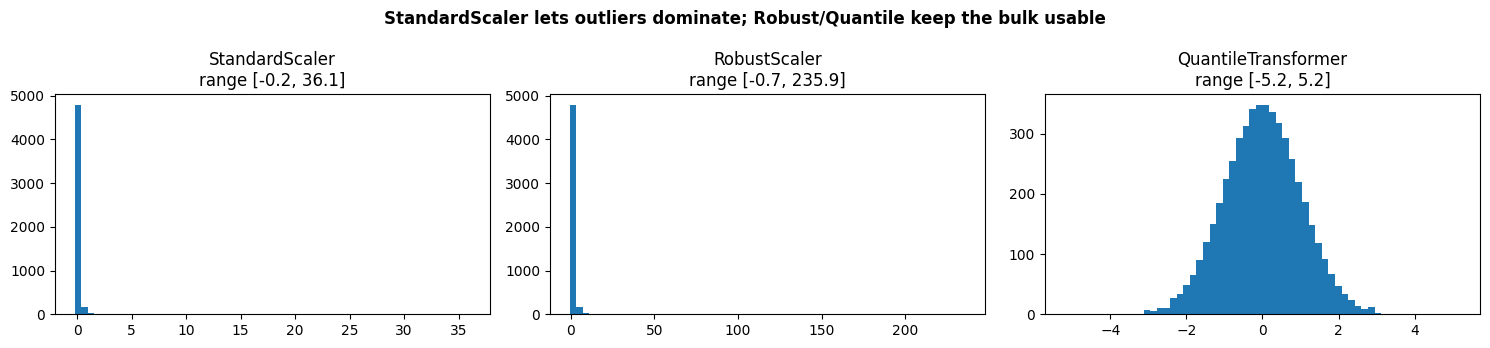

In [6]:
# DEMO E — Flow features are heavy-tailed; the scaler choice changes everything.
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
x = np.r_[rng.lognormal(0,1,5000), rng.lognormal(0,1,50)*50]   # skewed + a few huge outliers
x = x.reshape(-1,1)
fig, ax = plt.subplots(1,3, figsize=(15,3.5))
for a,(name,sc) in zip(ax, {"StandardScaler":StandardScaler(),
                            "RobustScaler":RobustScaler(),
                            "QuantileTransformer":QuantileTransformer(output_distribution="normal",
                                                                      n_quantiles=500)}.items()):
    xs = sc.fit_transform(x).ravel()
    a.hist(xs, bins=60); a.set_title(f"{name}\nrange [{xs.min():.1f}, {xs.max():.1f}]")
plt.suptitle("StandardScaler lets outliers dominate; Robust/Quantile keep the bulk usable",
             fontweight="bold"); plt.tight_layout(); plt.show()

In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — swap the scaler where you currently use StandardScaler
from sklearn.preprocessing import RobustScaler, QuantileTransformer
# scaler = StandardScaler()                                   # <- your current line
scaler = RobustScaler()                                       # robust to outliers
# scaler = QuantileTransformer(output_distribution="normal", n_quantiles=1000)  # strongest option
X_train_scaled = scaler.fit_transform(X_train)                # fit on SOURCE benign only
X_test_2018_scaled = scaler.transform(X_test_2018)            # apply to targets (no refit)
# Re-run a model (e.g. the autoencoder/VAE) and compare F1 / PR-AUC to StandardScaler.

## F. Quantify the dataset shift (KS + Wasserstein)

**Why:** your PCA/clustering *shows* shift; a table *measures* it and tells you exactly which features break
transfer — strong material for your RQ4 and discussion.

**The fix:** for every aligned feature, compute the Kolmogorov–Smirnov statistic and the Wasserstein
distance between source and target, then rank.

**How to read the demo:** larger KS / Wasserstein = bigger shift; those top features are why transfer fails.

In [7]:
# DEMO F — Quantify dataset shift per feature (turns your PCA picture into numbers).
from scipy.stats import ks_2samp, wasserstein_distance
src = rng.normal(0,1,(5000,6))
tgt = src.copy()
tgt[:,0]+=2.5; tgt[:,1]*=2.0; tgt[:,2]+=0.3          # f0,f1 shift a lot; f2 a little; f3-5 unchanged
cols=[f"f{i}" for i in range(6)]
shift=[]
for j,c in enumerate(cols):
    ks=ks_2samp(src[:,j],tgt[:,j]).statistic
    w =wasserstein_distance(src[:,j],tgt[:,j])
    shift.append({"Feature":c,"KS_statistic":round(ks,3),"Wasserstein":round(w,3)})
shift_df=pd.DataFrame(shift).sort_values("Wasserstein",ascending=False).reset_index(drop=True)
print("Bigger KS / Wasserstein = larger shift = the features that break transfer. Rank and report the top ones.\n")
shift_df

Bigger KS / Wasserstein = larger shift = the features that break transfer. Rank and report the top ones.



,Feature,KS_statistic,Wasserstein
0,f0,0.796,2.500
1,f1,0.160,0.809
2,f2,0.123,0.300
3,f3,0.000,0.000
4,f4,0.000,0.000
5,f5,0.000,0.000


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — per-feature shift table (2017 vs 2018 vs NF-UNSW)
from scipy.stats import ks_2samp, wasserstein_distance
def shift_table(src, tgt, feats, sample=20000):
    rows=[]
    for f in feats:
        a = pd.to_numeric(src[f], errors="coerce").dropna().sample(min(sample,len(src)), random_state=0)
        b = pd.to_numeric(tgt[f], errors="coerce").dropna().sample(min(sample,len(tgt)), random_state=0)
        rows.append({"Feature":f,
                     "KS":round(ks_2samp(a,b).statistic,3),
                     "Wasserstein":round(wasserstein_distance(a,b),3)})
    return pd.DataFrame(rows).sort_values("Wasserstein", ascending=False).reset_index(drop=True)

print(shift_table(data_2017, data_2018, common_features).head(10))
# Repeat with data_unsw + the 22-feature set to show NF-UNSW shifts more.

## G. Extra anomaly baselines: LOF + PCA reconstruction

**Why:** two cheap, well-known detectors broaden your comparison, and a **rank-average ensemble** of all
detectors is frequently the most shift-robust option — a nice "best we can do" line.

**How to read the demo:** both score with an honest benign-percentile threshold, directly comparable to your five models.

In [8]:
# DEMO G — Cheap extra anomaly baselines: LOF (novelty) and PCA reconstruction error.
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
Xtr = rng.normal(0,1,(4000,20))                       # benign-only training
Xte = np.r_[rng.normal(0,1,(3000,20)), rng.normal(1.5,1,(1000,20))]
yte = np.r_[np.zeros(3000), np.ones(1000)]

lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(Xtr)
lof_score = -lof.decision_function(Xte)               # higher = more anomalous
pca = PCA(n_components=8).fit(Xtr)
recon = ((Xte - pca.inverse_transform(pca.transform(Xte)))**2).mean(1)

rows=[]
for name,sc in {"LOF":lof_score,"PCA-reconstruction":recon}.items():
    thr=np.quantile(sc[yte==0], 0.95)                 # honest threshold on benign
    rows.append({"Detector":name, **metrics(yte, (sc>=thr).astype(int), sc)})
print("Drop-in alternatives to your five models; a rank-average ensemble of detectors is often the most shift-robust.\n")
pd.DataFrame(rows)

Drop-in alternatives to your five models; a rank-average ensemble of detectors is often the most shift-robust.



,Detector,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,LOF,0.961,0.869,0.992,0.926,0.998,0.996
1,PCA-reconstruction,0.961,0.869,0.995,0.928,0.999,0.996


In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — LOF + PCA-reconstruction on your scaled features
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
lof = LocalOutlierFactor(n_neighbors=20, novelty=True).fit(X_train_scaled)   # benign 2017 only
pca = PCA(n_components=10).fit(X_train_scaled)
def pca_recon_error(X): return ((X - pca.inverse_transform(pca.transform(X)))**2).mean(1)

for name, Xte, yt in [("CICIDS2018", X_test_2018_scaled, y_test_2018_unsup),
                      ("NF-UNSW",    X_test_unsw_scaled,  y_test_unsw)]:
    for det, sc in [("LOF", -lof.decision_function(Xte)),
                    ("PCA-recon", pca_recon_error(Xte))]:
        thr = np.quantile(sc[yt==0], 0.95)
        pred = (sc >= thr).astype(int)
        print(name, det, "F1=", round(f1_score(yt,pred,zero_division=0),3),
              "PR_AUC=", round(average_precision_score(yt, sc),3))

## H. Explainability — fulfil your XAI section (permutation importance / SHAP)

**Why:** your thesis discusses SHAP/LIME but never runs them. Permutation importance is one line and
shows which features the model relies on; comparing source-vs-target importance explains *why* transfer fails.

**How to read the demo:** the bar chart correctly flags the two informative features as the drivers.

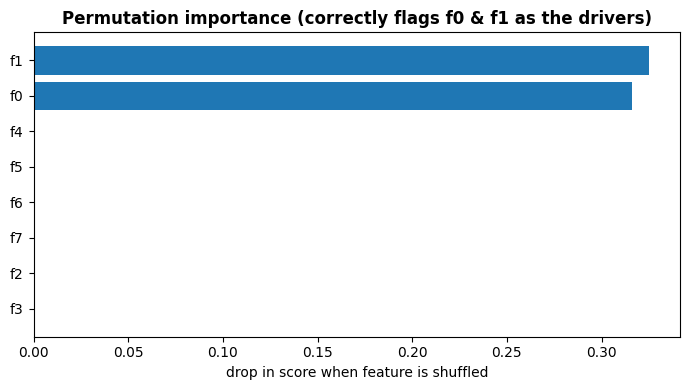

Run the same on your RF and on autoencoder reconstruction error to fulfil your XAI section,
and to explain WHICH shifted features destroy cross-dataset transfer.


In [9]:
# DEMO H — Explainability: which features actually drive the model? (permutation importance)
from sklearn.inspection import permutation_importance
Xp = rng.normal(0,1,(3000,8)); yp = (Xp[:,0]+Xp[:,1]>0).astype(int)   # only f0,f1 matter
cols=[f"f{i}" for i in range(8)]
rf = RandomForestClassifier(n_estimators=200,random_state=0).fit(Xp,yp)
imp = permutation_importance(rf, Xp, yp, n_repeats=10, random_state=0)
order=np.argsort(imp.importances_mean)
plt.figure(figsize=(7,4))
plt.barh([cols[i] for i in order], imp.importances_mean[order])
plt.title("Permutation importance (correctly flags f0 & f1 as the drivers)", fontweight="bold")
plt.xlabel("drop in score when feature is shuffled"); plt.tight_layout(); plt.show()
print("Run the same on your RF and on autoencoder reconstruction error to fulfil your XAI section,")
print("and to explain WHICH shifted features destroy cross-dataset transfer.")

In [ ]:
# 📌 PASTE INTO YOUR NOTEBOOK — permutation importance + (optional) SHAP on your RF
from sklearn.inspection import permutation_importance
imp = permutation_importance(rf_model, X_test_rf_scaled, y_test_rf, n_repeats=5, random_state=0, n_jobs=-1)
order = np.argsort(imp.importances_mean)[-15:]
plt.figure(figsize=(8,5))
plt.barh([common_features[i] for i in order], imp.importances_mean[order])
plt.title("Random Forest — permutation importance (top 15)"); plt.tight_layout(); plt.show()

# Optional SHAP (tree models):
# import shap; expl = shap.TreeExplainer(rf_model)
# shap.summary_plot(expl.shap_values(X_test_rf_scaled[:2000]), X_test_rf_scaled[:2000],
#                   feature_names=common_features)

---
### How to use this in your write-up
- **Method chapter:** describe the honest-threshold rule (B) and the time-based split (D) as your evaluation protocol.
- **Results chapter:** add the 22-feature ablation table (A), the trivial-baseline rows (C), the shift table (F), and the LOF/PCA baselines (G).
- **Discussion / XAI:** use the importance + shift comparison (F + H) to explain *which* features stop transferring.
- **Limitations → Future work:** robust scaling (E) and the detector ensemble (G) are natural "next steps".

Together these turn "performance dropped" into a *measured, explained, and honestly-evaluated* story — exactly what a cross-dataset generalisation thesis needs.